<a href="https://colab.research.google.com/github/Copperhorse/CurrencyClassification/blob/main/Testing_currencyClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:

import numpy as np
import timm
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from torch.utils.data import DataLoader

In [ ]:
print(os.listdir(path))
path = os.path.join(path,'Pakistan')


['Pakistan']


In [ ]:
print(os.listdir(path+'/Valid'))


['10Rsback', '20Rsback', '50Rs', '10Rs', '5000Rs', 'others', '50Rsback', '1000Rsback', '5000Rsback', '500Rs', '500Rsback', '100Rsback', '100Rs', '1000Rs', '20Rs']


In [ ]:
class CustomPreprocessing:
    def __init__(self, apply_equalization=False, apply_denoise=False, apply_edges=False):
        self.apply_equalization = apply_equalization
        self.apply_denoise = apply_denoise
        self.apply_edges = apply_edges

    def __call__(self, img: Image.Image):
        # Convert to OpenCV format
        img_np = np.array(img)

        # Apply histogram equalization (grayscale only)
        if self.apply_equalization:
            if len(img_np.shape) == 3 and img_np.shape[2] == 3:
                img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
            img_np = cv2.equalizeHist(img_np)

        # Denoising
        if self.apply_denoise:
            img_np = cv2.medianBlur(img_np, 3)

        # Edge detection (Canny)
        if self.apply_edges:
            img_np = cv2.Canny(img_np, 100, 200)

        # Convert back to 3-channel image if needed
        if len(img_np.shape) == 2:
            img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)

        # Convert back to PIL for further torchvision transforms
        return Image.fromarray(img_np)


In [ ]:
transform = transforms.Compose([
    CustomPreprocessing(
        apply_equalization=False,
        apply_denoise=True,
        apply_edges=False  # set to True if needed
    ),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # For RGB images
])

In [ ]:
train_dataset = datasets.ImageFolder(root=path+'/Training', transform=transform)
test_dataset = datasets.ImageFolder(root=path+'/Valid', transform=transform)

In [ ]:
train_dataLoader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataLoader = DataLoader(test_dataset, batch_size=3216, shuffle=False)

In [ ]:
print(len(train_dataset.classes))

15


In [ ]:
train_dataset.class_to_idx

{'1000Rs': 0,
 '1000Rsback': 1,
 '100Rs': 2,
 '100Rsback': 3,
 '10Rs': 4,
 '10Rsback': 5,
 '20Rs': 6,
 '20Rsback': 7,
 '5000Rs': 8,
 '5000Rsback': 9,
 '500Rs': 10,
 '500Rsback': 11,
 '50Rs': 12,
 '50Rsback': 13,
 'others': 14}

In [ ]:
# # 5. Evaluation
# correct = 0
# total = 0
# model.eval()  # Set to evaluation mode
# with torch.no_grad():
#     for images, labels in test_dataLoader:
#         images, labels = images.to(device), labels.to(device)
#         outputs = model(images)
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()

# accuracy = 100 * correct / total
# print(f"Accuracy of the model on the test images: {accuracy:.2f}%")


Accuracy of the model on the test images: 97.05%


In [ ]:
# torch.save(model.state_dict(), 'currency_classifier_model.pth')
# print("Model saved as currency_classifier_model.pth")


Model saved as currency_classifier_model.pth


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # Define device here
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=len(train_dataset.classes)) # Load without pretrained weights
# Explicitly load to CPU if CUDA is not available
model.load_state_dict(torch.load('/content/currency_classifier_model.pth', map_location=torch.device('cpu')))
model = model.to(device) # Now you can safely move it to the correct device
model.eval() # Set the model to evaluation mode

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [ ]:
sum_list = []

In [ ]:
import cv2

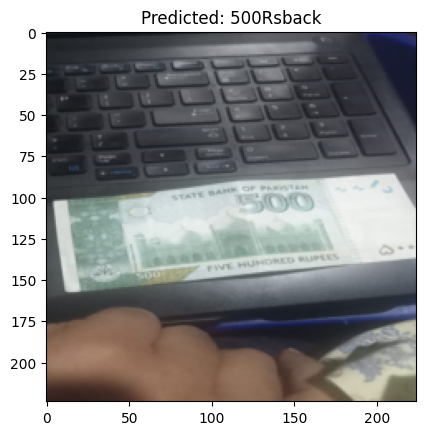

[50, 1000, 1000, 500, 5000, 500, 20, 500, 50, 500]


In [ ]:
import random
import matplotlib.pyplot as plt
import re
from PIL import Image # Import Image


# Assuming 'test_dataset' and 'model' are defined as in the provided code

image = Image.open("/content/WhatsApp Image 2025-05-02 at 4.17.51 AM.jpeg").convert('RGB') # Open the image using PIL and ensure it's RGB
image = transform(image)  # Apply the same transformations used during training
image = image.unsqueeze(0)  # Add a batch dimension
# Make a prediction
model.eval()  # Ensure the model is in evaluation mode
with torch.no_grad():

    output = model(image)
    _, predicted = torch.max(output, 1)

# Get the class name from the predicted label
class_names = test_dataset.classes
predicted_class = class_names[predicted.item()]
# actual_class = class_names[label] # This line causes an error because 'label' is not defined. You need to provide the actual label.

# Extract integer part from predicted_class and append to sum_list
try:
    integer_part = re.search(r'\d+', predicted_class).group()
    integer_num = int(integer_part)
    sum_list.append(integer_num)
except (ValueError, AttributeError):
    print(f"Could not extract integer from: {predicted_class}")

# Display the image and prediction
image_np = image.squeeze(0).cpu().numpy()
image_np = image_np * 0.5 + 0.5  # Reverse mean and std normalization
image_np = np.clip(image_np, 0, 1)
image_np = np.transpose(image_np, (1, 2, 0))

plt.imshow(image_np)
plt.title(f"Predicted: {predicted_class}") # Removed actual_class since 'label' was undefined.
plt.show()

print(sum_list)  # Print the list of extracted integers

In [ ]:
sum_of_numbers = __builtins__.sum(sum_list)
print(f"The sum of numbers in sum_list is: {sum_of_numbers}")

The sum of numbers in sum_list is: 7550
